Generando boxplots iniciales...


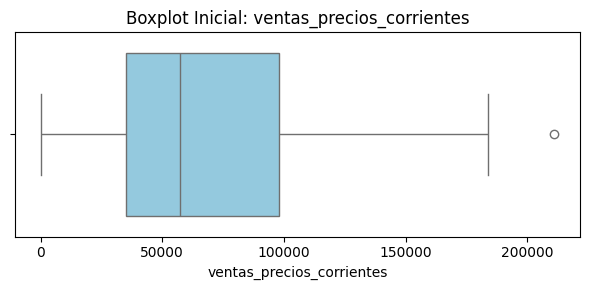

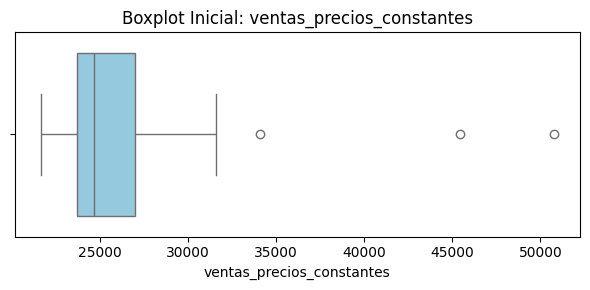

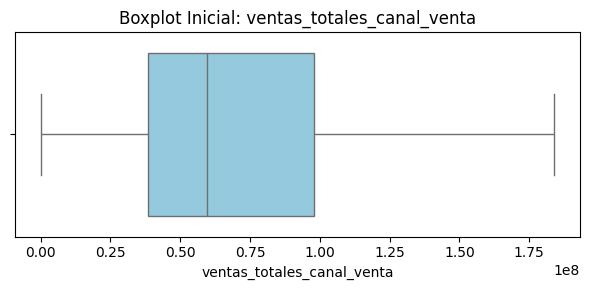

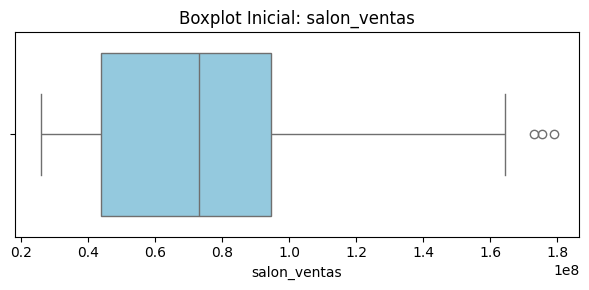

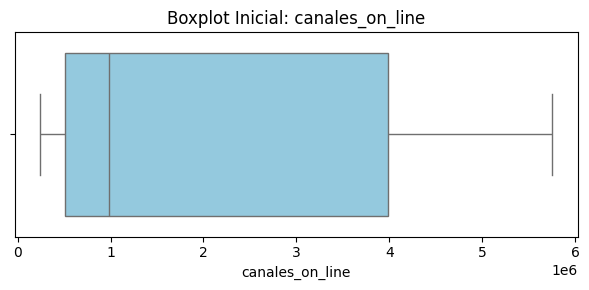

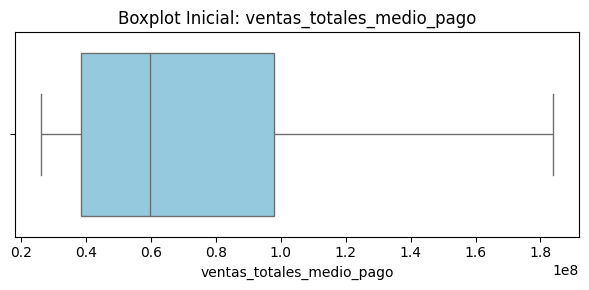

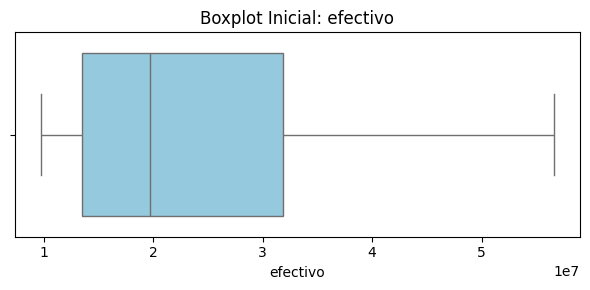

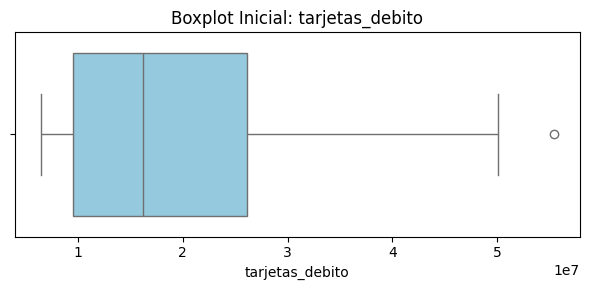

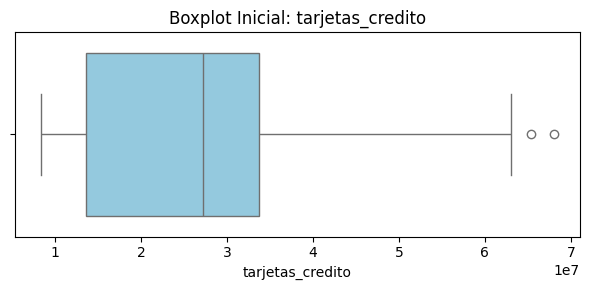

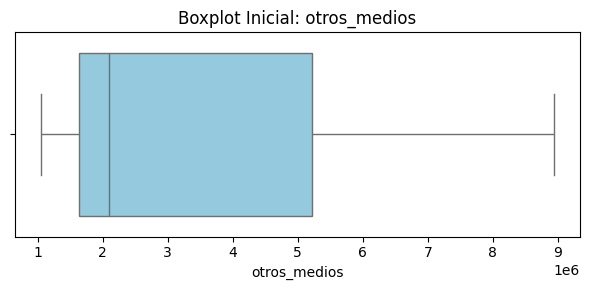

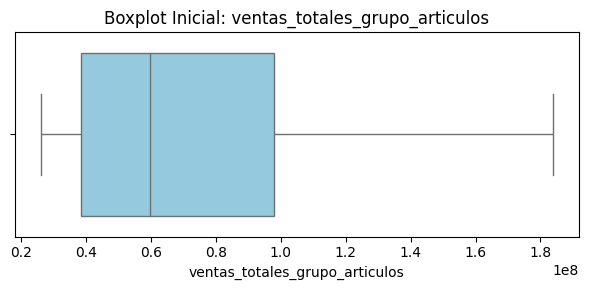

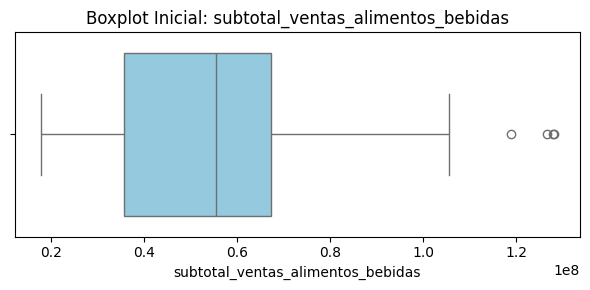

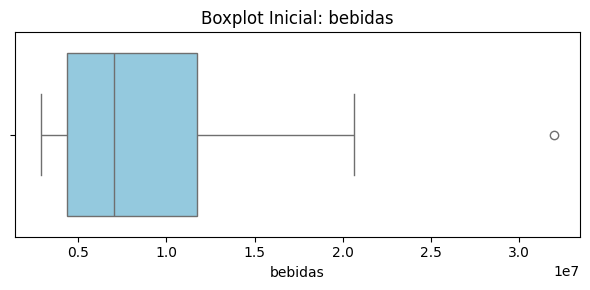

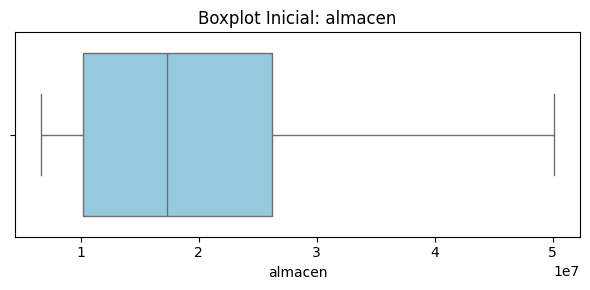

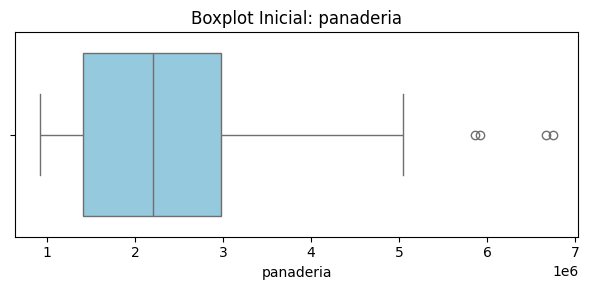

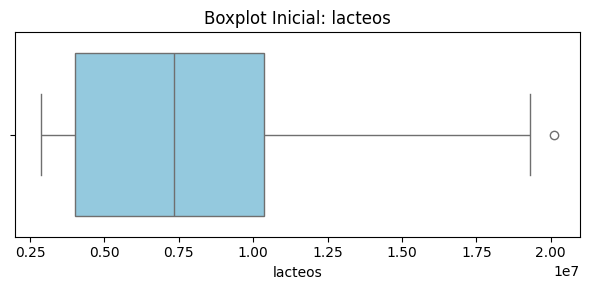

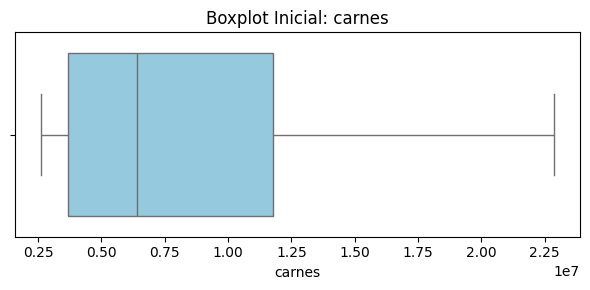

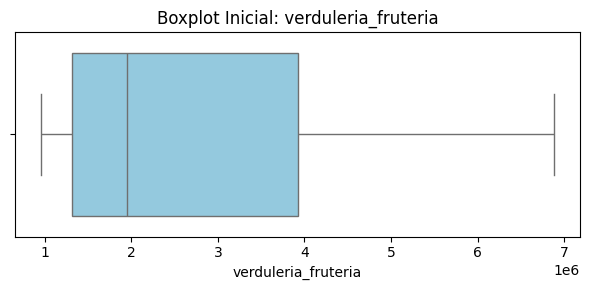

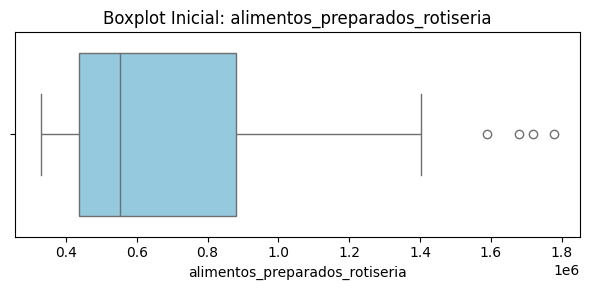

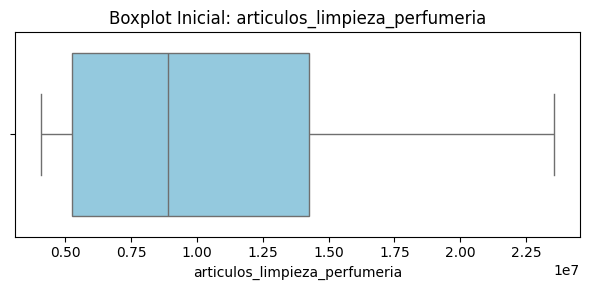

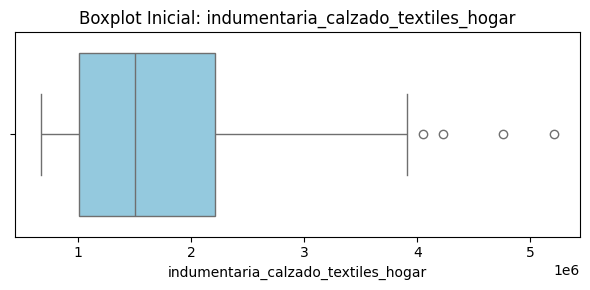

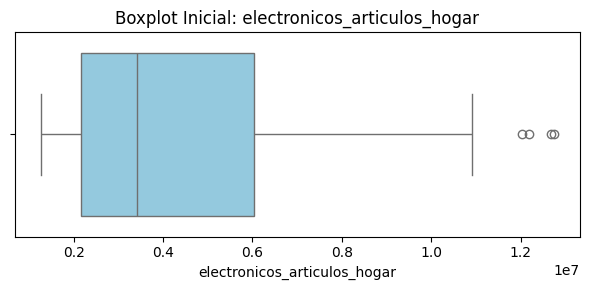

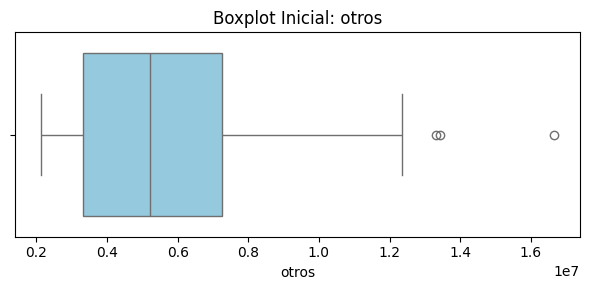

Generando boxplots finales tras imputar con Mediana (Std Dev)...


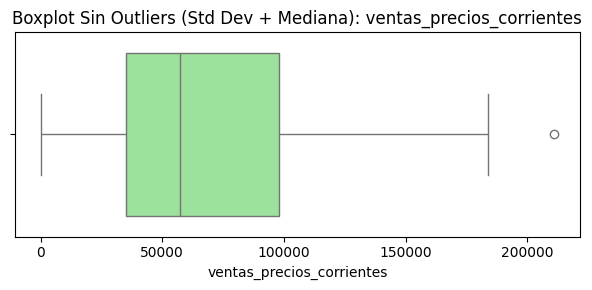

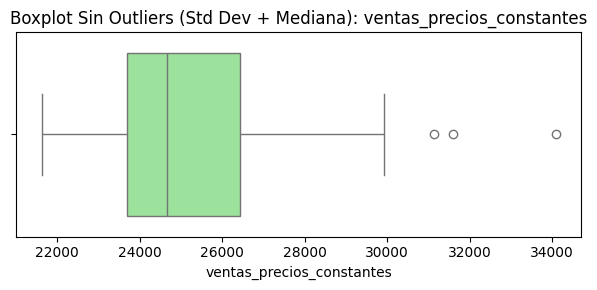

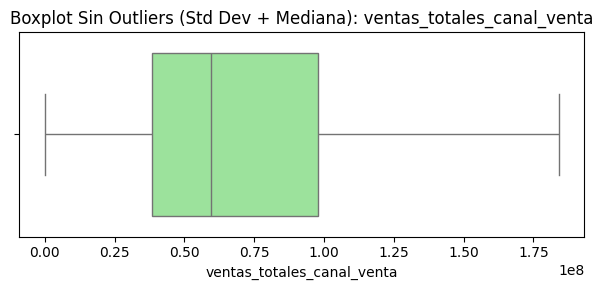

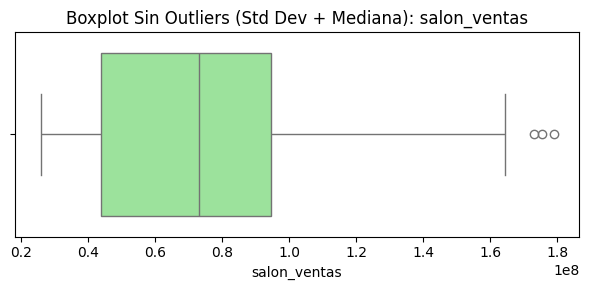

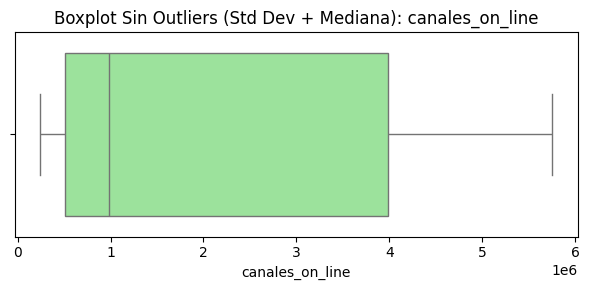

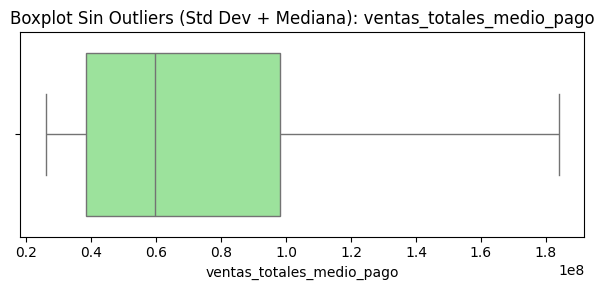

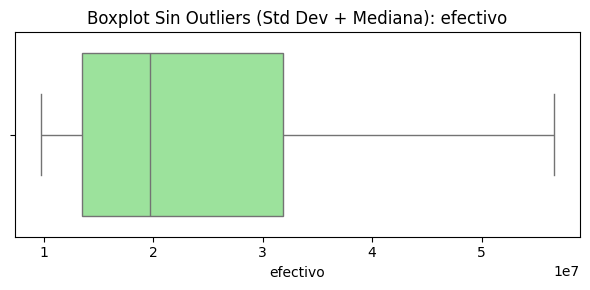

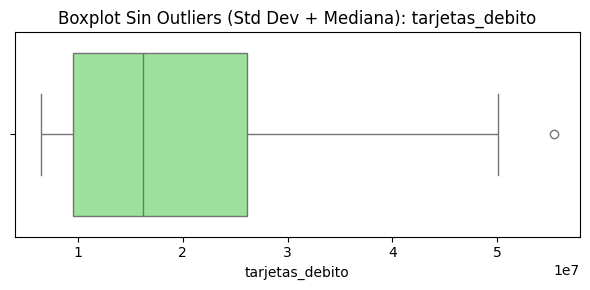

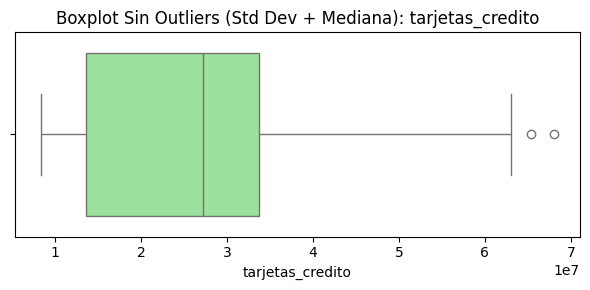

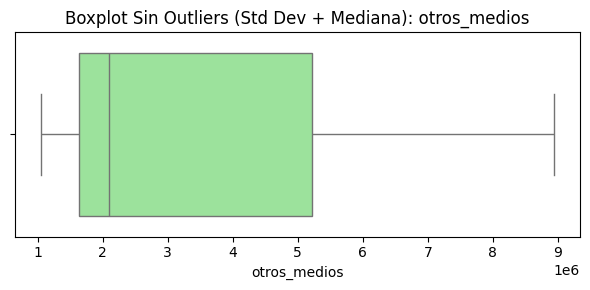

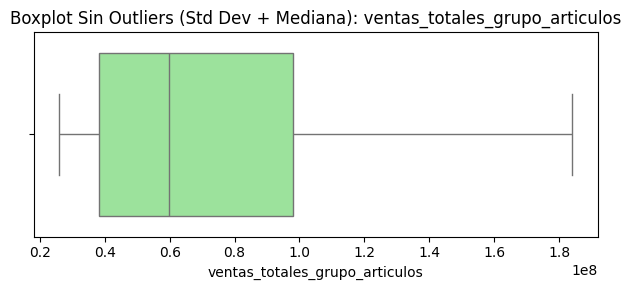

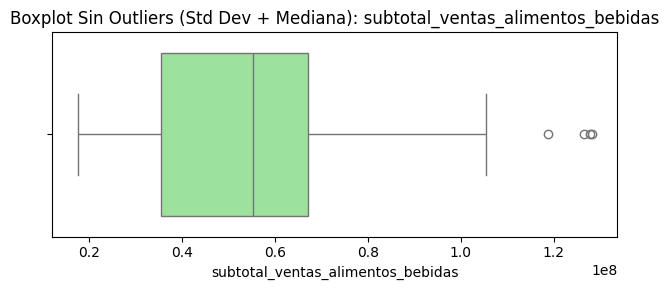

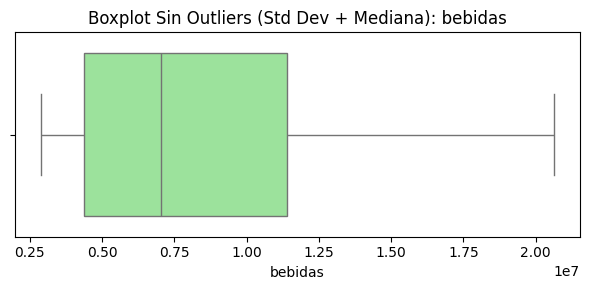

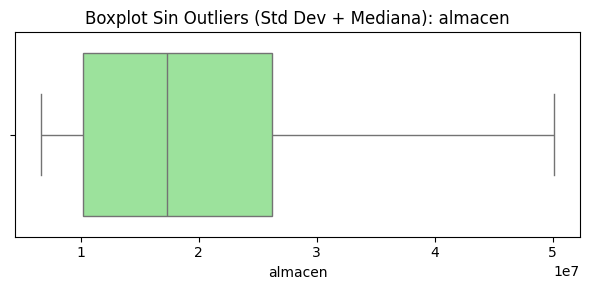

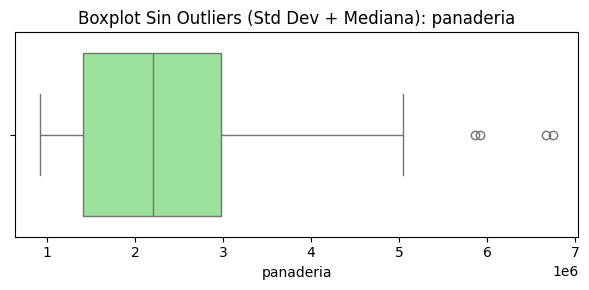

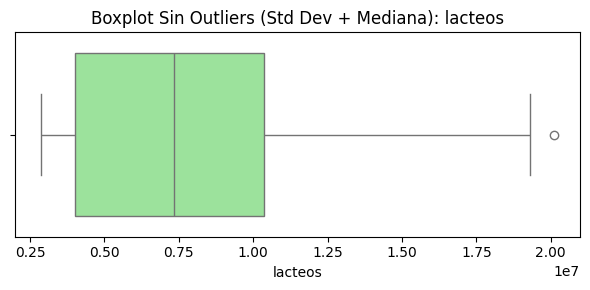

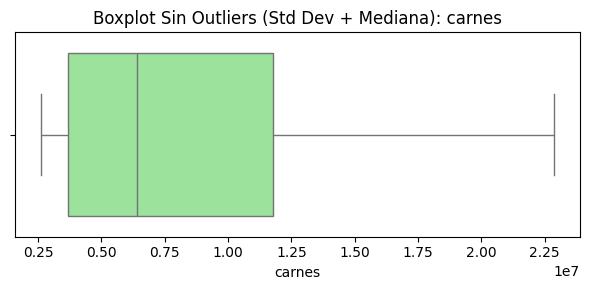

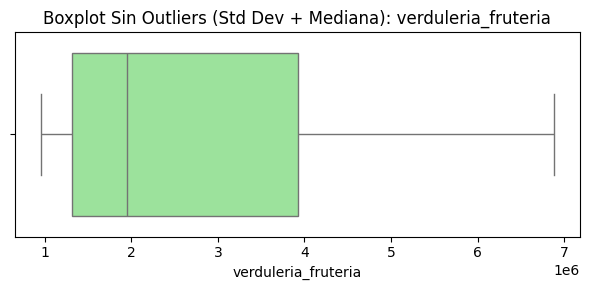

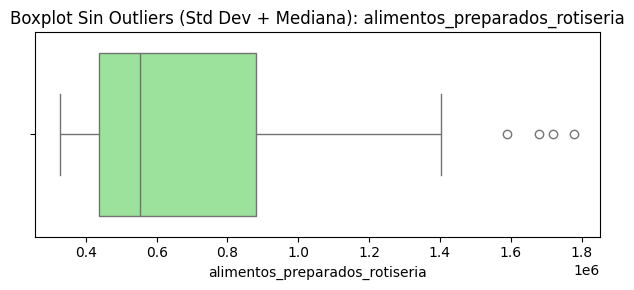

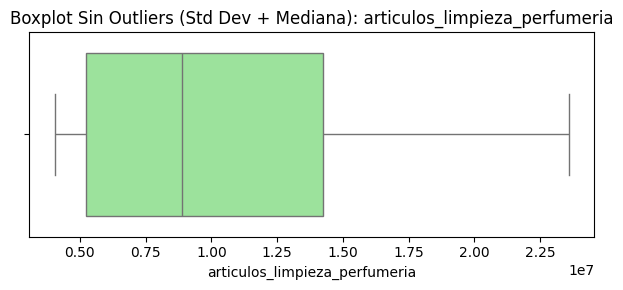

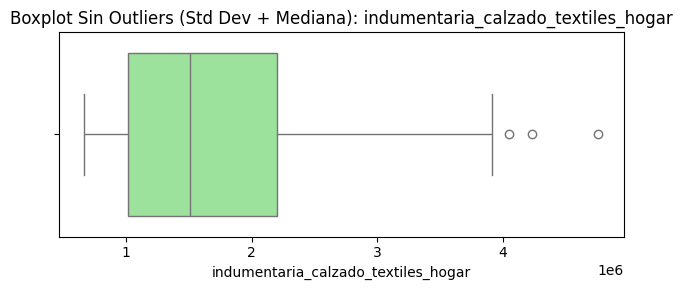

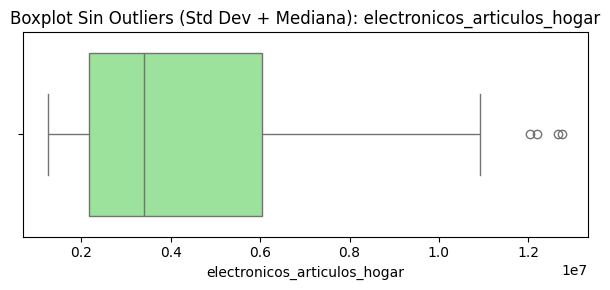

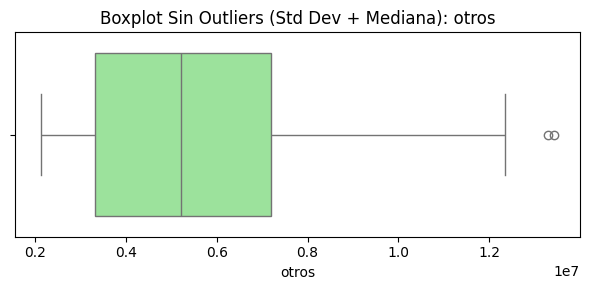

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Cargar el DataFrame correspondiente a la imagen
df = pd.read_csv("VentasTotales_Limpio.csv")

# Seleccionar únicamente variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns

# ---------------------------------------------------------
# 2. DIAGRAMAS DE CAJA (BOXPLOTS) ANTES DE TRATAR OUTLIERS
# ---------------------------------------------------------
print("Generando boxplots iniciales...")
for col in num_cols:
  plt.figure(figsize=(6, 3))
  sns.boxplot(x=df[col], color="skyblue")
  plt.title(f"Boxplot Inicial: {col}")
  plt.tight_layout()
  plt.show()

# ---------------------------------------------------------
# 3. TRATAMIENTO DE OUTLIERS: DESVIACIÓN ESTÁNDAR E IMPUTACIÓN CON MEDIANA
# ---------------------------------------------------------
# Método Desviación Estándar (Criterio de 3 desviaciones estándar)
df_limpio_std = df.copy()

for col in num_cols:
  media = df_limpio_std[col].mean()
  std = df_limpio_std[col].std()
  mediana = df_limpio_std[col].median()

  limite_inferior = media - 3 * std
  limite_superior = media + 3 * std

  # Identificar valores fuera de rango
  outliers = (df_limpio_std[col] < limite_inferior) | (
      df_limpio_std[col] > limite_superior
  )

  # Reemplazar valores atípicos con la mediana de la columna
  df_limpio_std.loc[outliers, col] = mediana

# ---------------------------------------------------------
# 4. TRATAMIENTO DE OUTLIERS: RANGO INTERCUARTÍLICO (IQR)
# ---------------------------------------------------------
df_limpio_iqr = df.copy()

for col in num_cols:
  Q1 = df_limpio_iqr[col].quantile(0.25)
  Q3 = df_limpio_iqr[col].quantile(0.75)
  IQR = Q3 - Q1
  mediana = df_limpio_iqr[col].median()

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  # Identificar valores fuera de rango
  outliers = (df_limpio_iqr[col] < limite_inferior) | (
      df_limpio_iqr[col] > limite_superior
  )

  # Reemplazar valores atípicos con la mediana de la columna
  df_limpio_iqr.loc[outliers, col] = mediana

# ---------------------------------------------------------
# 5. DIAGRAMAS DE CAJA (BOXPLOTS) DESPUÉS DEL TRATAMIENTO (Desviación Estándar)
# ---------------------------------------------------------
print("Generando boxplots finales tras imputar con Mediana (Std Dev)...")
for col in num_cols:
  plt.figure(figsize=(6, 3))
  sns.boxplot(x=df_limpio_std[col], color="lightgreen")
  plt.title(f"Boxplot Sin Outliers (Std Dev + Mediana): {col}")
  plt.tight_layout()
  plt.show()

# ---------------------------------------------------------
# 6. EXPORTAR RESULTADOS
# ---------------------------------------------------------
df_limpio_std.to_csv("VentasTotales_SinOutliers_StdDev.csv", index=False)
df_limpio_iqr.to_csv("VentasTotales_SinOutliers_IQR.csv", index=False)